# Parte 5 · Explicabilidad y Mapas de Activación con Grad-CAM

**Visión por Computadora II · CEIA · FIUBA**

En este notebook implementamos **Grad-CAM** (*Gradient-weighted Class Activation Mapping*, Selvaraju et al., 2017) para auditar e interpretar visualmente las decisiones tomadas por el mejor modelo entrenado en `03_finetuning_transfer_learning.ipynb`.

### Fundamento Matemático de Grad-CAM
Para una capa convolucional profunda $A$ con canales $A^k$ y un puntaje logit $y^c$ para la clase $c$ (previo a softmax):
1. **Ponderación de canales $\alpha_k^c$:** Se calcula el promedio espacial (Global Average Pooling) del gradiente del score $y^c$ respecto a cada posición $(i, j)$ del mapa $A^k$:
$$\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A_{i, j}^k}$$
2. **Mapa de activación:** Se combinan linealmente los mapas ponderados y se aplica $\text{ReLU}$ para conservar únicamente las activaciones con impacto favorable sobre la clase $c$:
$$L_{\text{Grad-CAM}}^c = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)$$


## 0. Configuración y Dependencias


In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn.functional as F

from common import ROOT, DATA_DIR, CACHE_DIR, finetune_model, load_split, make_transforms, DEVICE

# Configuración de reproducibilidad y visualización
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

IMG_SIZE = 160
_, eval_tf = make_transforms(IMG_SIZE, augment=False)
df, classes = load_split()
short_classes = [c.replace("__", "_").replace("_", " ") for c in classes]

if DEVICE.type == "cuda":
    print(f"Dispositivo en uso: {DEVICE} ({torch.cuda.get_device_name(0)})")
else:
    print(f"Dispositivo en uso: {DEVICE} (no se detectó GPU)")
print(f"Total de clases cargadas: {len(classes)}")


Dispositivo en uso: cpu (no se detectó GPU)
Total de clases cargadas: 15


## 1. Selección y Carga del Modelo Final

Se usa como modelo final **EfficientNet-B0 con data augmentation** (`effb0_aug`), el mismo de la demo (notebook 06). En validación, las dos variantes de EfficientNet-B0 quedan prácticamente empatadas (diferencia del orden de 10⁻⁴ en macro-F1, dentro del ruido entre corridas), y la versión con augmentation es mucho más robusta ante perturbaciones (notebook 04). Los checkpoints no se versionan (`cache/` está en `.gitignore`), así que **si el checkpoint no existe se reentrena automáticamente** con la misma configuración del notebook 03 (160×160, 8 épocas, batch 32). Se usa la GPU si está disponible (unos minutos); en CPU tarda alrededor de una hora. Como el entrenamiento no es determinístico, las métricas pueden diferir levemente de las del summary.

In [2]:
import json, time
from torch.utils.data import DataLoader
from common import PlantDataset, fit, predict, metrics

# Cargar el ranking de experimentos del notebook 03
summary_path = ROOT / "results" / "finetune_full" / "summary.csv"
if not summary_path.exists():
    raise FileNotFoundError(f"No se encontró {summary_path}. Asegúrate de haber completado las corridas del notebook 03.")

summary = pd.read_csv(summary_path)
print("=== Resumen de experimentos de fine-tuning ===")
display(summary.round(4))

# Modelo final: effb0_aug (empatado en validación con effb0_noaug y más robusto según el notebook 04)
FINAL_RUN = "effb0_aug"
best_row = summary[summary["corrida"] == FINAL_RUN].iloc[0]
BEST_NAME = best_row["corrida"]
BEST_ARCH = best_row["modelo"]
BEST_AUGMENT = bool(best_row["augmentation"])
N_UNFREEZE = 3 if "effb0" in BEST_NAME else 6

print(f"\n-> Modelo final: {BEST_NAME} ({BEST_ARCH})")
print(f"   Val macro-F1: {best_row['val macro-F1']:.4f} | Test macro-F1: {best_row['test macro-F1']:.4f}")

ckpt_path = CACHE_DIR / "ckpt_full" / f"{BEST_NAME}.pt"

def train_checkpoint(epochs=8, batch_size=32):
    """Reentrena la corrida elegida con la configuración del notebook 03 y guarda el checkpoint."""
    print(f"\nNo existe {ckpt_path.name}: se reentrena {BEST_NAME} en {DEVICE}...")
    torch.manual_seed(42)
    splits = {s: df[df.split == s].reset_index(drop=True) for s in ["train", "val", "test"]}
    train_tf, val_tf = make_transforms(IMG_SIZE, BEST_AUGMENT)
    gpu = DEVICE.type == "cuda"
    mk = lambda d, tf, shuffle, nw: DataLoader(PlantDataset(d, transform=tf), batch_size=batch_size, shuffle=shuffle,
                                               num_workers=nw, persistent_workers=nw > 0, pin_memory=gpu)
    n_workers = min(4, max(1, (os.cpu_count() or 2) // 2))
    train_loader = mk(splits["train"], train_tf, True, n_workers)
    val_loader, test_loader = mk(splits["val"], val_tf, False, 2), mk(splits["test"], val_tf, False, 2)

    model = finetune_model(BEST_ARCH, len(classes), N_UNFREEZE)
    t0 = time.time()
    history, best_state = fit(model, train_loader, val_loader, epochs,
                              log_path=CACHE_DIR / f"{BEST_NAME}_retrain.log", device=DEVICE)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(best_state, ckpt_path)

    model.load_state_dict(best_state)
    test_logits, yt = predict(model, test_loader, device=DEVICE)
    m = metrics(yt, test_logits.argmax(1))
    info = {"corrida": BEST_NAME, "device": str(DEVICE), "minutos": (time.time() - t0) / 60,
            **{f"test_{k}": v for k, v in m.items()}}
    json.dump(info, open(CACHE_DIR / f"{BEST_NAME}_retrain.json", "w"), indent=2)
    print(f"Checkpoint guardado ({info['minutos']:.1f} min) | test macro-F1 {m['macro_f1']:.4f} "
          f"(summary: {best_row['test macro-F1']:.4f})")

if not ckpt_path.exists():
    train_checkpoint()

# Instanciar arquitectura y cargar el checkpoint de pesos
net = finetune_model(BEST_ARCH, len(classes), N_UNFREEZE)
net.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
net.to(DEVICE)
net.eval()
print(f"Modelo cargado exitosamente en {DEVICE} desde: {ckpt_path.name}")

=== Resumen de experimentos de fine-tuning ===


,corrida,modelo,augmentation,params entrenables (M),mejor época,val macro-F1,test accuracy,test balanced acc,test macro-F1,min,linear probe test macro-F1 (nb 02)
0,mnv3s_noaug,mobilenet_v3_small,False,1.39,6,0.9919,0.9915,0.9886,0.9873,12.9,0.9585
1,mnv3s_aug,mobilenet_v3_small,True,1.39,8,0.9849,0.9888,0.9823,0.9853,13.9,0.9585
2,effb0_noaug,efficientnet_b0,False,3.17,5,0.9942,0.9936,0.9903,0.9903,72.2,0.9610
3,effb0_aug,efficientnet_b0,True,3.17,8,0.9938,0.9942,0.9922,0.9927,55.4,0.9610



-> Modelo final: effb0_aug (efficientnet_b0)
   Val macro-F1: 0.9938 | Test macro-F1: 0.9927


Modelo cargado exitosamente en cpu desde: effb0_aug.pt


## 2. Inspección de la Capa Convolucional Objetivo

Para Grad-CAM seleccionamos la **última capa convolucional** del backbone:
- En **EfficientNet-B0**: `net.features[-1]` (`Conv2dNormActivation`), que emite mapas de características de `[B, 1280, 5, 5]`.
- En **MobileNetV3-Small**: `net.features[-1]` (`Conv2dNormActivation`), con dimensiones `[B, 576, 5, 5]`.

Esta capa retiene la información espacial necesaria antes del *Global Average Pooling* final, combinada con la semántica más profunda.


In [3]:
target_layer = net.features[-1]
print("Capa objetivo para Grad-CAM:")
print(target_layer)

# Verificación de dimensiones con un tensor de prueba
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    feat_out = target_layer(net.features[:-1](dummy) if len(net.features) > 1 else dummy)
    logits_out = net(dummy)

print(f"\nShape activación espacial en target_layer: {tuple(feat_out.shape)}")
print(f"Shape de logits de salida: {tuple(logits_out.shape)}")


Capa objetivo para Grad-CAM:
Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)

Shape activación espacial en target_layer: (1, 1280, 5, 5)
Shape de logits de salida: (1, 15)


## 3. Implementación del Motor `GradCAM`

Implementamos la clase `GradCAM` utilizando hooks nativos de PyTorch (`register_forward_hook` y `register_full_backward_hook`).
Se encarga de:
1. Capturar activaciones y gradientes hacia atrás del score de interés.
2. Calcular la importancia $\alpha_k^c$ por canal mediante GAP.
3. Computar la combinación lineal y rectificación ReLU.
4. Normalizar el mapa $[0, 1]$ e interpolarlo a la resolución de entrada.
5. Superponerlo sobre la imagen original mediante mapas de color colormap (ej. `jet`).


In [4]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        self.fwd_hook = self.target_layer.register_forward_hook(self._save_activations)
        self.bwd_hook = self.target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, inp, out):
        self.activations = out

    def _save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate_cam(self, x, class_idx=None):
        """
        Calcula el mapa de activación Grad-CAM para el tensor de entrada x [1, 3, H, W].
        Si class_idx es None, se utiliza la clase predicha con mayor probabilidad.
        """
        self.model.zero_grad()
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
            
        score = logits[0, class_idx]
        score.backward(retain_graph=True)
        
        # 1. Global Average Pooling (GAP) de los gradientes por canal
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        
        # 2. Combinación ponderada de las activaciones espaciales
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True) # [1, 1, H_feat, W_feat]
        
        # 3. Rectificación ReLU: conservamos solo rasgos que aumentan el logit de la clase
        cam = F.relu(cam)
        
        # 4. Interpolación bilineal al tamaño del tensor de entrada
        cam_resized = F.interpolate(cam, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=False)
        cam_np = cam_resized.squeeze().detach().cpu().numpy()
        
        # 5. Normalización min-max a [0, 1]
        c_min, c_max = cam_np.min(), cam_np.max()
        if c_max > c_min:
            cam_norm = (cam_np - c_min) / (c_max - c_min)
        else:
            cam_norm = np.zeros_like(cam_np)
            
        probs = F.softmax(logits, dim=1).squeeze().detach().cpu().numpy()
        return cam_norm, probs, class_idx

    @staticmethod
    def overlay_cam(img_pil, cam, alpha=0.5, colormap="jet"):
        """
        Superpone el heatmap [0, 1] sobre la imagen original PIL con transparencia alpha.
        """
        img_resized = img_pil.resize(cam.shape[::-1])
        img_np = np.array(img_resized).astype(np.float32) / 255.0
        
        cmap = plt.get_cmap(colormap)
        heatmap_rgba = cmap(cam)
        heatmap_rgb = heatmap_rgba[:, :, :3]
        
        # Mezcla ponderada
        overlay = (1 - alpha) * img_np + alpha * heatmap_rgb
        overlay = np.clip(overlay, 0.0, 1.0)
        return img_np, heatmap_rgb, overlay

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

gradcam = GradCAM(net, target_layer)
print("Motor GradCAM inicializado y listo para inferencia.")


Motor GradCAM inicializado y listo para inferencia.


## 4. Función de Visualización Diagnóstica

Creamos una función para examinar una muestra foliar:
1. **Imagen original** con su etiqueta verdadera (*Ground Truth*).
2. **Mapa de calor Grad-CAM** (regiones de máxima relevancia destacadas en rojo/amarillo).
3. **Superposición** para correlacionar la activación con las manchas de la hoja.
4. **Gráfico de barras** con las *Top-K* probabilidades predichas.


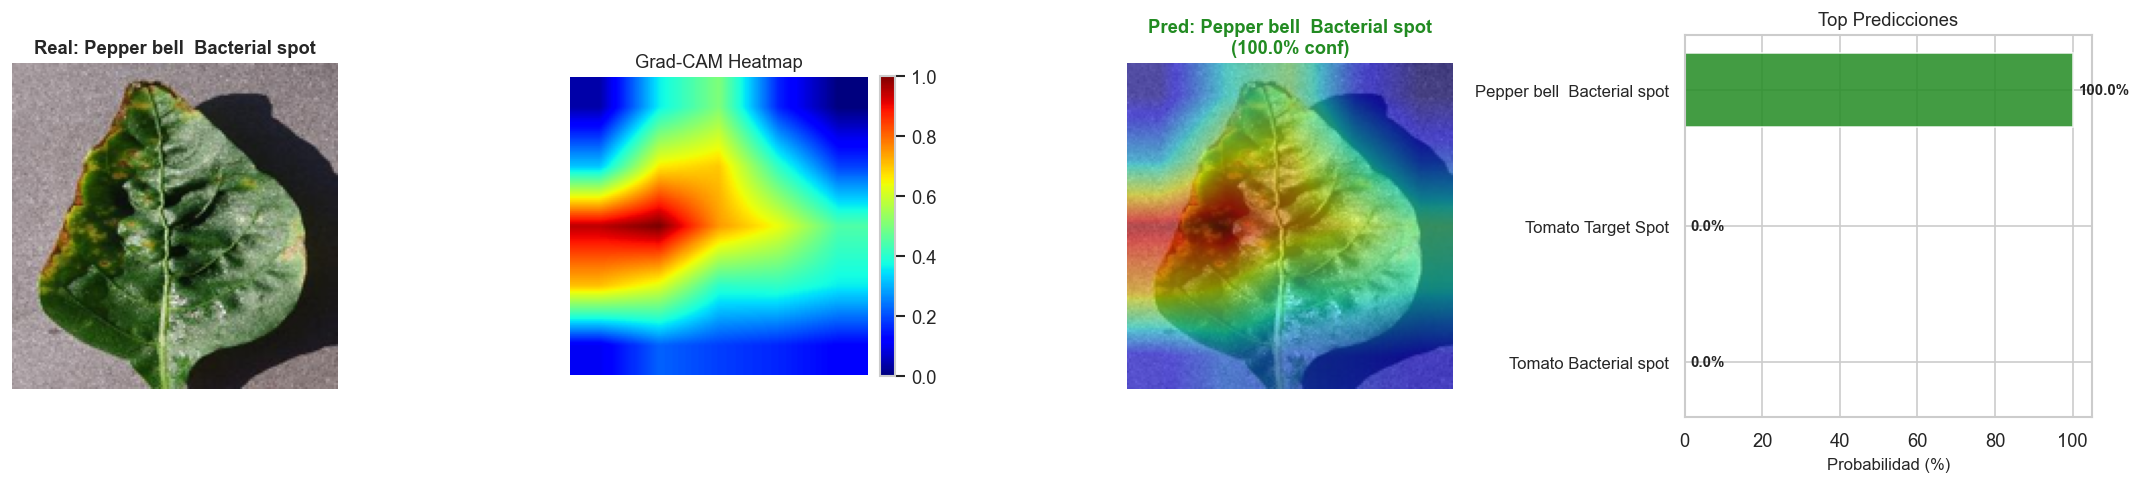

In [5]:
def plot_gradcam_diagnostic(relpath, true_label_idx, target_class=None, top_k=3):
    img_path = DATA_DIR / relpath
    img_pil = Image.open(img_path).convert("RGB")
    x = eval_tf(img_pil).unsqueeze(0).to(DEVICE)
    
    cam, probs, pred_idx = gradcam.generate_cam(x, class_idx=target_class)
    img_np, heat_np, overlay_np = GradCAM.overlay_cam(img_pil, cam, alpha=0.5, colormap="jet")
    
    true_label = short_classes[true_label_idx]
    pred_label = short_classes[pred_idx]
    confidence = probs[pred_idx] * 100.0
    is_correct = (pred_idx == true_label_idx)
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), gridspec_kw={"width_ratios": [1, 1, 1, 1.25]})
    
    # 1. Imagen Original
    axes[0].imshow(img_np)
    axes[0].set_title(f"Real: {true_label}", fontsize=11, fontweight="bold")
    axes[0].axis("off")
    
    # 2. Mapa de Calor
    im1 = axes[1].imshow(cam, cmap="jet", vmin=0, vmax=1)
    axes[1].set_title("Grad-CAM Heatmap", fontsize=11)
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    # 3. Superposición (Overlay)
    axes[2].imshow(overlay_np)
    title_color = "forestgreen" if is_correct else "crimson"
    axes[2].set_title(f"Pred: {pred_label}\n({confidence:.1f}% conf)", fontsize=11, color=title_color, fontweight="bold")
    axes[2].axis("off")
    
    # 4. Distribución de Probabilidades
    top_indices = np.argsort(probs)[-top_k:][::-1]
    top_probs = probs[top_indices] * 100.0
    top_labels = [short_classes[i] for i in top_indices]
    
    colors = ["forestgreen" if idx == true_label_idx else ("crimson" if idx == pred_idx else "steelblue") for idx in top_indices]
    y_pos = np.arange(len(top_labels))
    axes[3].barh(y_pos, top_probs, color=colors, alpha=0.85, height=0.55)
    axes[3].set_yticks(y_pos)
    axes[3].set_yticklabels(top_labels, fontsize=10)
    axes[3].invert_yaxis()
    axes[3].set_xlabel("Probabilidad (%)", fontsize=10)
    axes[3].set_xlim(0, 105)
    for i, p in enumerate(top_probs):
        axes[3].text(p + 1.5, i, f"{p:.1f}%", va="center", fontsize=9, fontweight="bold")
    axes[3].set_title("Top Predicciones", fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Verificamos con la primera muestra de test
test_df = df[df.split == "test"].reset_index(drop=True)
sample_row = test_df.iloc[0]
plot_gradcam_diagnostic(sample_row["relpath"], sample_row["y"])


## 5. Casos de Estudio en el Conjunto de Test

Seleccionamos casos representativos para evaluar diferentes tipos de sintomatología vegetal:
1. **Lesiones Fúngicas / Bacterianas Localizadas:** (*Early blight*, *Bacterial spot*, *Septoria leaf spot*) → Verificamos si la activación se concentra en las manchas necróticas y anillos.
2. **Infecciones Sistémicas / Virales:** (*Tomato Yellow Leaf Curl Virus*, *Tomato Mosaic Virus*) → Observamos si atiende a la deformación foliar, rizado marginal y moteado.


Visualizando casos de estudio seleccionados:


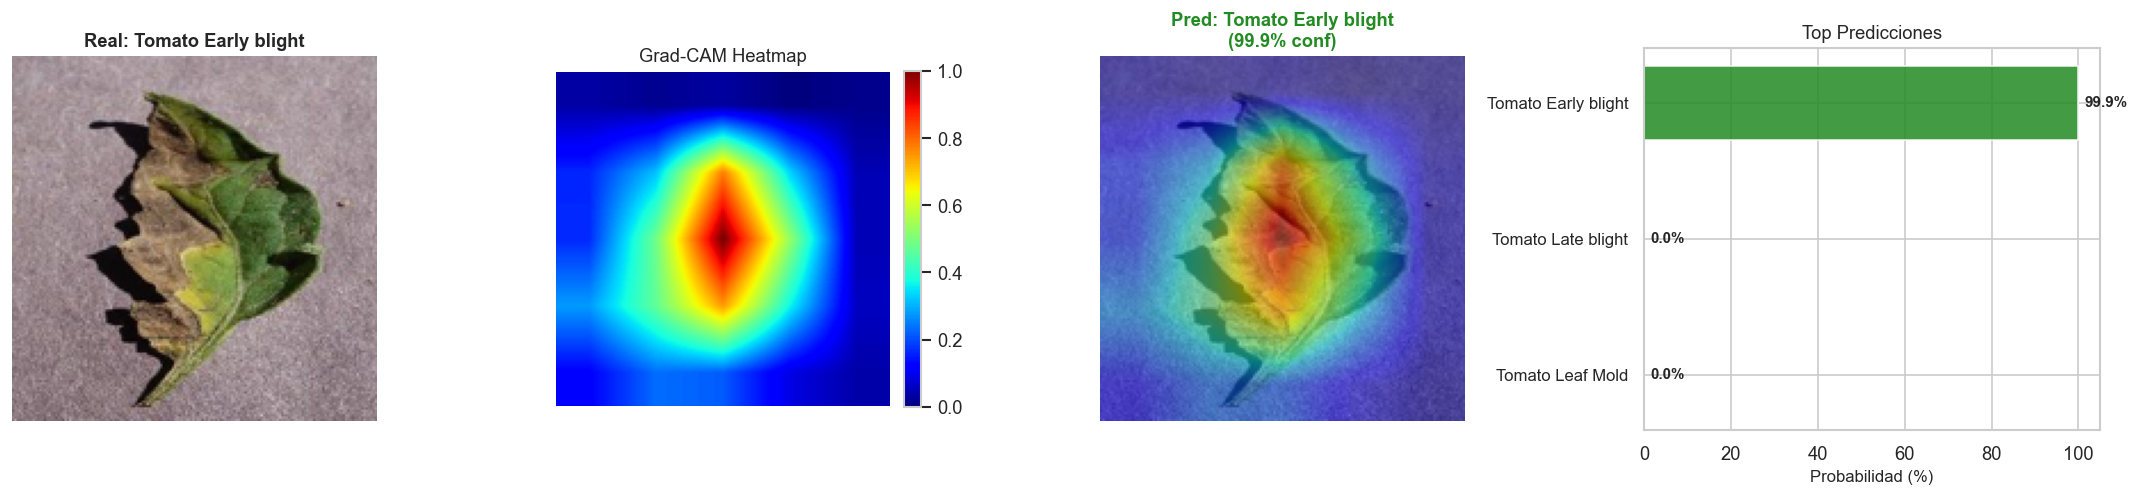

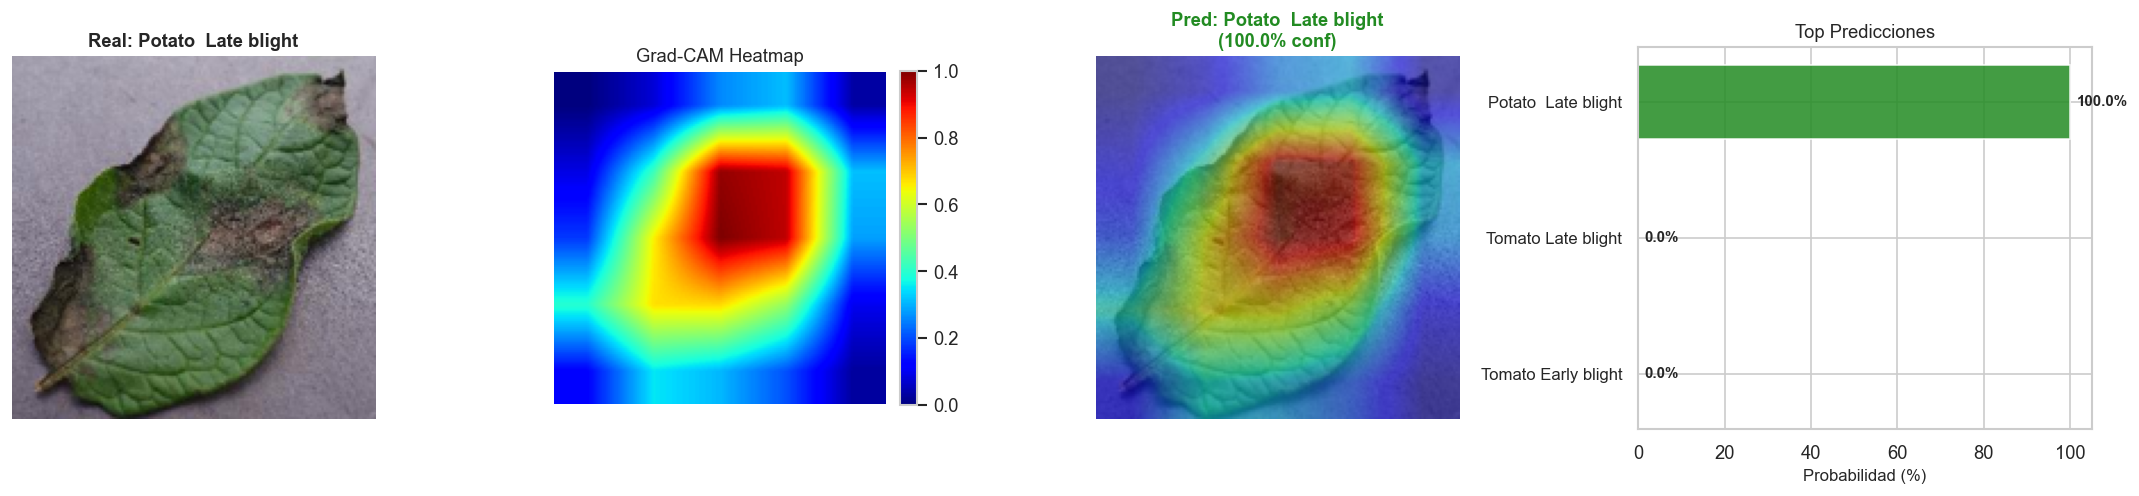

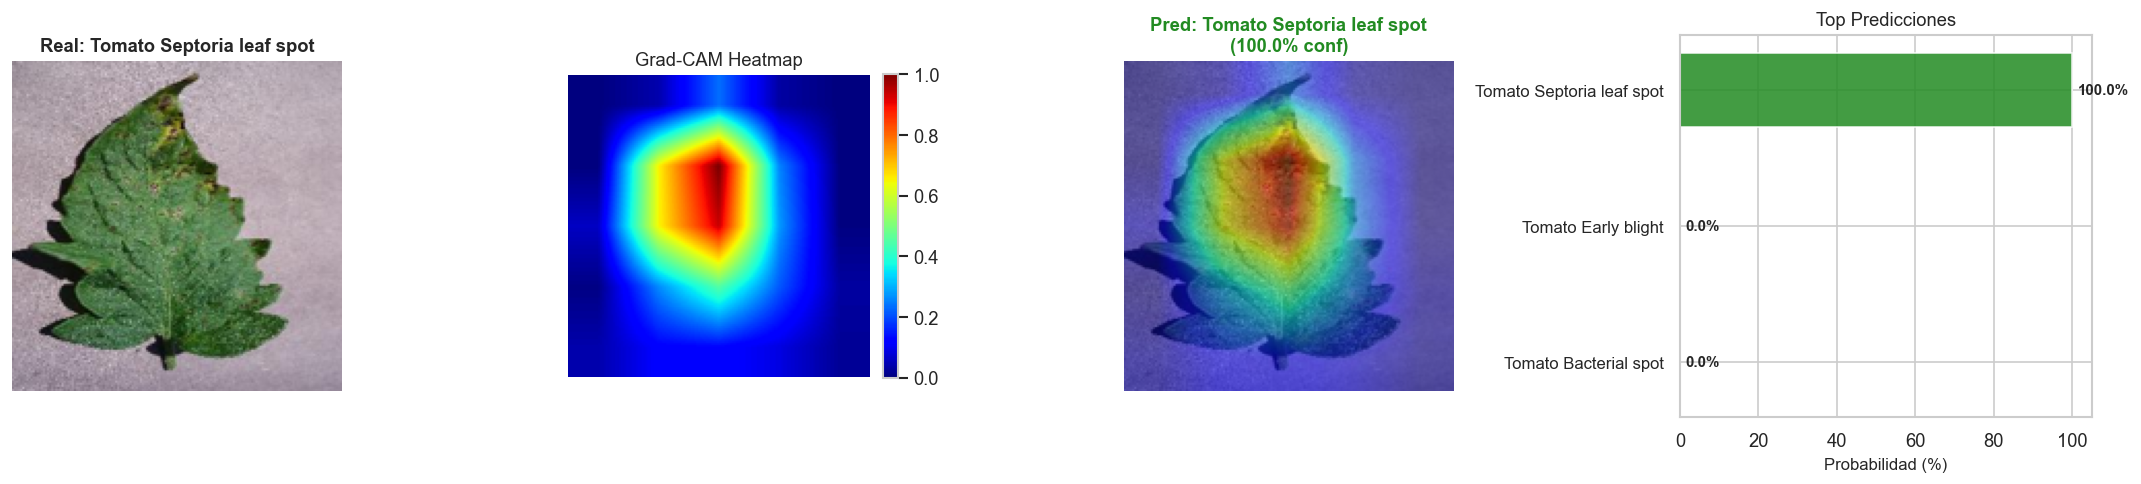

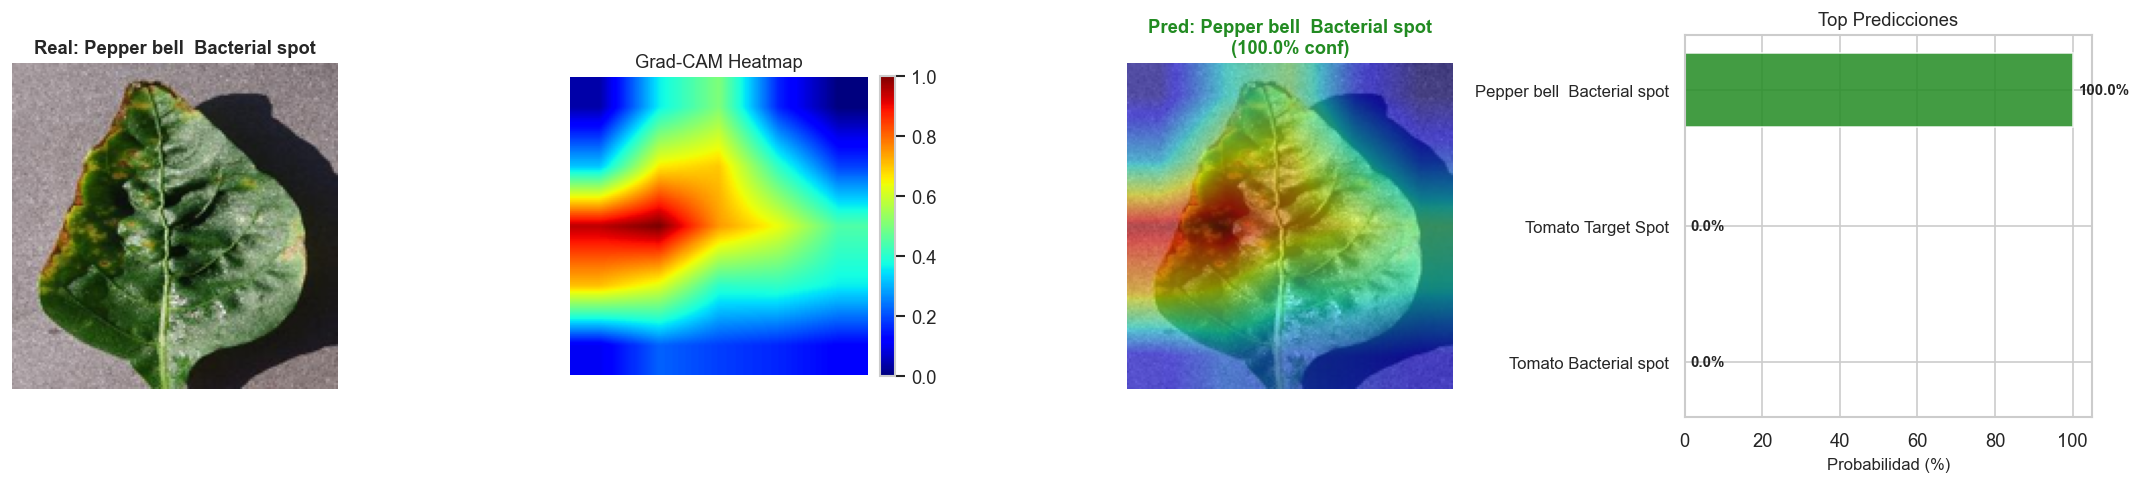

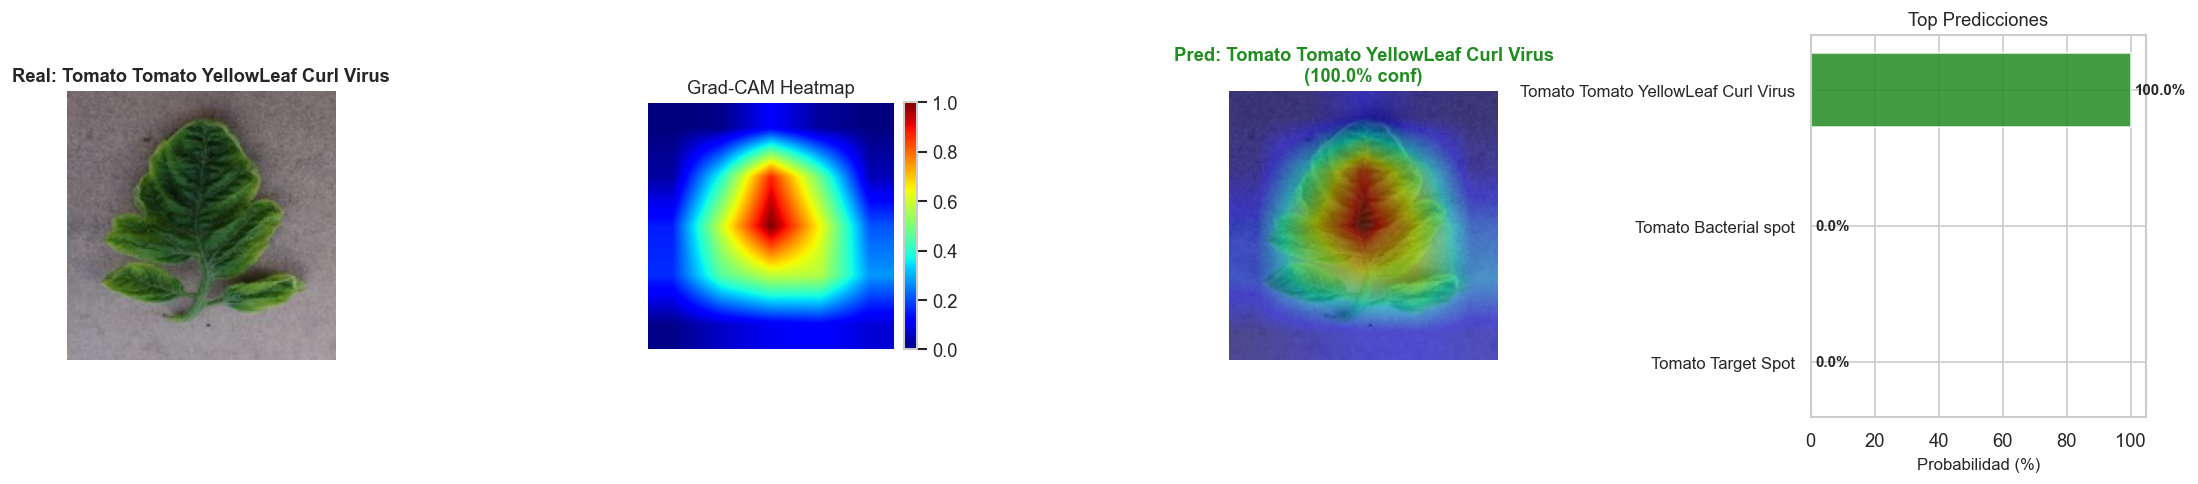

In [6]:
case_classes = [
    "Tomato_Early_blight",
    "Potato___Late_blight",
    "Tomato_Septoria_leaf_spot",
    "Pepper__bell___Bacterial_spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
]

print("Visualizando casos de estudio seleccionados:")
for cls_name in case_classes:
    cls_idx = classes.index(cls_name)
    candidates = test_df[test_df.y == cls_idx]
    if len(candidates) > 0:
        row = candidates.iloc[0]
        plot_gradcam_diagnostic(row["relpath"], row["y"])


## 6. Galería Comparativa Multiclase (Grid de Explicabilidad)

Presentamos una cuadrícula de 8 muestras aleatorias del conjunto de test que cubren diversas clases, excluyendo hojas sanas.


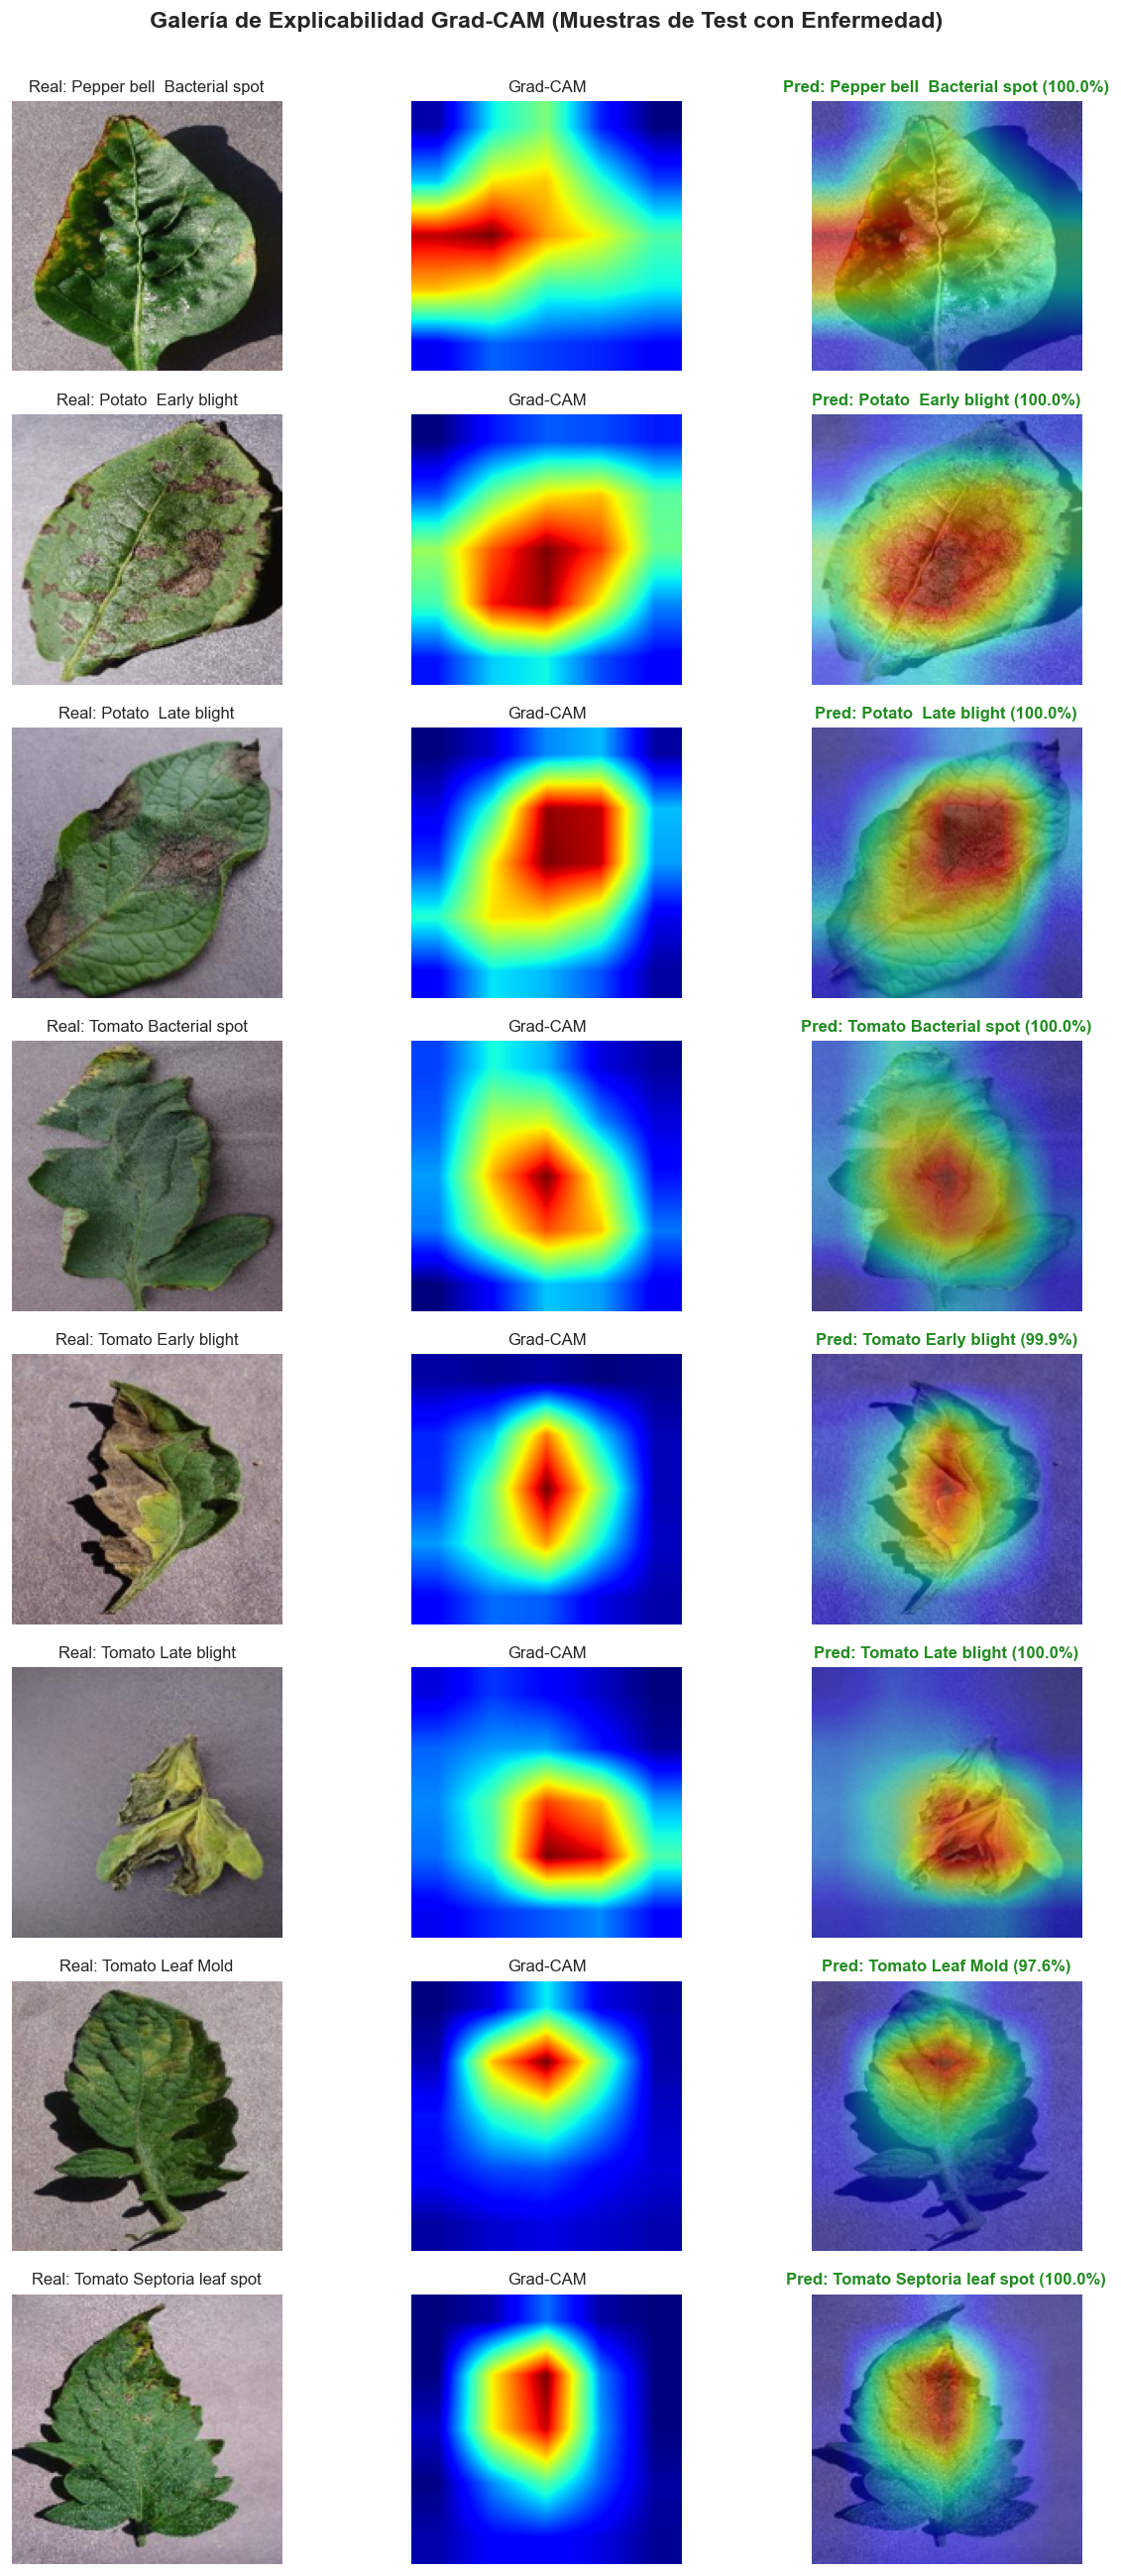

In [7]:
# Seleccionar 8 imágenes de distintas clases con enfermedad (excluyendo 'healthy')
disease_classes = [i for i, name in enumerate(classes) if "healthy" not in name.lower()][:8]
selected_rows = [test_df[test_df.y == i].iloc[0] for i in disease_classes]
selected_df = pd.DataFrame(selected_rows).reset_index(drop=True)

n_samples = len(selected_df)
fig, axes = plt.subplots(n_samples, 3, figsize=(11, 2.7 * n_samples))

for i, (_, row) in enumerate(selected_df.iterrows()):
    img_path = DATA_DIR / row["relpath"]
    img_pil = Image.open(img_path).convert("RGB")
    x = eval_tf(img_pil).unsqueeze(0).to(DEVICE)
    
    cam, probs, pred_idx = gradcam.generate_cam(x)
    img_np, heat_np, overlay_np = GradCAM.overlay_cam(img_pil, cam, alpha=0.5, colormap="jet")
    
    true_label = short_classes[row["y"]]
    pred_label = short_classes[pred_idx]
    conf = probs[pred_idx] * 100
    
    # 1. Original
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Real: {true_label}", fontsize=10)
    axes[i, 0].axis("off")
    
    # 2. Heatmap
    axes[i, 1].imshow(cam, cmap="jet", vmin=0, vmax=1)
    axes[i, 1].set_title("Grad-CAM", fontsize=10)
    axes[i, 1].axis("off")
    
    # 3. Superposición
    axes[i, 2].imshow(overlay_np)
    color = "forestgreen" if pred_idx == row["y"] else "crimson"
    axes[i, 2].set_title(f"Pred: {pred_label} ({conf:.1f}%)", fontsize=10, color=color, fontweight="bold")
    axes[i, 2].axis("off")

plt.suptitle("Galería de Explicabilidad Grad-CAM (Muestras de Test con Enfermedad)", fontsize=14, fontweight="bold", y=1.002)
plt.tight_layout()
plt.show()



## 7. Configuración para exportar figuras del paper

Las figuras del informe se guardan en `paper/figures/` en PDF (vectorial, listas para `\includegraphics`), con tamaños pensados para el formato IEEE: una columna mide 3,5 in y el ancho de página 7,16 in. Los resultados numéricos van a `results/gradcam/`.

En las figuras usamos los nombres de las clases en español.

In [8]:
import json, time, platform
from scipy import ndimage
from common import FIG_DIR, COL_W, PAGE_W, PAPER_RC, CLASS_NAMES_ES, save_paper_fig as save_fig

RES_DIR = ROOT / "results" / "gradcam"; RES_DIR.mkdir(parents=True, exist_ok=True)

es_classes = [CLASS_NAMES_ES[c] for c in classes]
es_two_lines = [n.replace(": ", "\n") for n in es_classes]  # especie / condición, para títulos angostos

## 8. Costo computacional: tamaño y latencia de inferencia

Para que el prototipo sea viable en un dispositivo sin GPU (por ejemplo una notebook o un celular en el campo), medimos **siempre en CPU** (y, si hay GPU disponible, también en GPU como referencia) la **latencia por imagen** (batch 1, el caso de uso real de la demo) y el **throughput** (batch 32), además del número de parámetros y el tamaño en memoria (fp32).

Medimos las dos arquitecturas del fine-tuning. La latencia depende solo de la arquitectura y no de los pesos, así que para MobileNetV3-Small no hace falta su checkpoint. Usamos modelos nuevos, sin los hooks de Grad-CAM, para no sumar overhead a la medición.

In [9]:
@torch.no_grad()
def measure_latency(model, device, batch_size=1, n_warmup=10, n_runs=100):
    model.eval()
    x = torch.randn(batch_size, 3, IMG_SIZE, IMG_SIZE, device=device)
    sync = torch.cuda.synchronize if device.type == "cuda" else (lambda: None)
    for _ in range(n_warmup):
        model(x)
    sync()
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        model(x)
        sync()
        times.append((time.perf_counter() - t0) * 1000)
    return np.array(times)

# La CPU es el escenario de despliegue; la GPU (si existe) se agrega como referencia
lat_devices = [torch.device("cpu")] + ([torch.device("cuda")] if torch.cuda.is_available() else [])
lat_rows = []
for arch, n_unf in [("mobilenet_v3_small", 6), ("efficientnet_b0", 3)]:
    m = finetune_model(arch, len(classes), n_unf).eval()
    for dev in lat_devices:
        m = m.to(dev)
        t1 = measure_latency(m, dev, batch_size=1)
        t32 = measure_latency(m, dev, batch_size=32, n_warmup=3, n_runs=20)
        lat_rows.append({
            "modelo": arch,
            "dispositivo": dev.type,
            "params (M)": sum(p.numel() for p in m.parameters()) / 1e6,
            "tamaño fp32 (MB)": sum(t.numel() * t.element_size() for t in m.state_dict().values()) / 1024**2,
            "latencia bs=1 media (ms)": t1.mean(),
            "latencia bs=1 p95 (ms)": np.percentile(t1, 95),
            "throughput bs=32 (img/s)": 32 / (t32.mean() / 1000),
        })
    del m

latency = pd.DataFrame(lat_rows).set_index(["modelo", "dispositivo"])
latency.to_csv(RES_DIR / "latencia.csv")
gpu_name = f" | GPU: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else ""
print(f"CPU: {platform.processor()} | hilos torch: {torch.get_num_threads()}{gpu_name} | entrada {IMG_SIZE}x{IMG_SIZE}")
latency.round(2)

CPU: Intel64 Family 6 Model 186 Stepping 3, GenuineIntel | hilos torch: 10 | entrada 160x160


,,params (M),tamaño fp32 (MB),latencia bs=1 media (ms),latencia bs=1 p95 (ms),throughput bs=32 (img/s)
modelo,dispositivo,,,,,
mobilenet_v3_small,cpu,1.53,5.90,7.15,9.09,931.17
efficientnet_b0,cpu,4.03,15.52,17.50,20.54,150.85


## 9. Grad-CAM cuantitativo: ¿el modelo mira la hoja o el fondo?

Las visualizaciones anteriores son cualitativas. Para tener un número, medimos sobre **todo el set de test** qué fracción de la activación de Grad-CAM cae sobre la hoja.

1. **Máscara de la hoja**: PlantVillage tiene fondo de laboratorio uniforme y poco saturado. Estimamos el color del fondo como la mediana de un borde de 6 px y segmentamos la hoja por su distancia cromática al fondo en el plano (a\*, b\*) de CIELAB, con umbral de Otsu (mínimo 8), limpieza morfológica, relleno de huecos y la componente conexa más grande. Usamos solo la cromaticidad (y no la luminancia) para que las sombras, que tienen el mismo tono que el fondo, no se confundan con la hoja; las lesiones oscuras interiores quedan incluidas al rellenar huecos. Una primera versión basada solo en la saturación (HSV) perdía las zonas necróticas y verde oscuro, y subestimaba el área de la hoja.
2. **Energía sobre la hoja**: $E_{hoja} = \sum (\text{CAM} \cdot M) / \sum \text{CAM}$. Si el mapa fuera uniforme, $E_{hoja}$ sería igual al área relativa de la hoja. Por eso también reportamos el **cociente $E_{hoja}$ / área** (> 1 indica que la atención se concentra en la hoja más de lo esperable por azar).
3. **Pointing game**: porcentaje de imágenes en las que el máximo del mapa cae dentro de la hoja.

Esto es relevante porque se conoce que PlantVillage tiene sesgos de fondo y de captura. Un modelo que clasificara por el fondo concentraría la activación fuera de la hoja.

Grad-CAM se calcula **en batch**: con BatchNorm en modo `eval`, cada muestra es independiente, por lo que el gradiente de la suma de los logits predichos da el gradiente de cada imagen por separado.

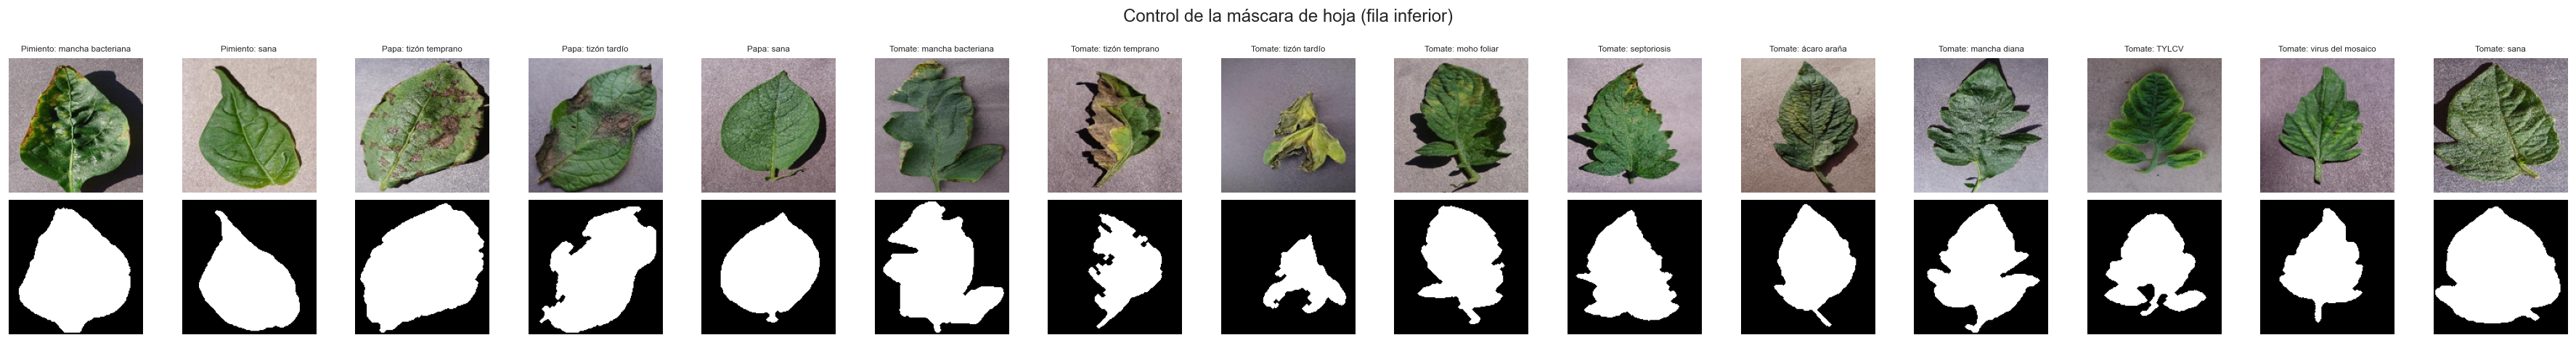

In [10]:
def otsu_threshold(values, bins=256):
    lo, hi = float(values.min()), float(values.max())
    hist, edges = np.histogram(values, bins=bins, range=(lo, hi + 1e-6))
    p = hist / hist.sum()
    centers = (edges[:-1] + edges[1:]) / 2
    w0 = np.cumsum(p); w1 = 1 - w0
    cum_mean = np.cumsum(p * centers)
    m0 = cum_mean / np.maximum(w0, 1e-12)
    m1 = (cum_mean[-1] - cum_mean) / np.maximum(w1, 1e-12)
    return centers[np.argmax(w0 * w1 * (m0 - m1) ** 2)]

def rgb2lab(rgb):
    """sRGB (uint8) -> CIELAB (D65)."""
    c = rgb.astype(np.float32) / 255
    c = np.where(c > 0.04045, ((c + 0.055) / 1.055) ** 2.4, c / 12.92)
    M = np.array([[0.4124, 0.3576, 0.1805], [0.2126, 0.7152, 0.0722], [0.0193, 0.1192, 0.9505]], np.float32)
    xyz = c @ M.T / np.array([0.95047, 1.0, 1.08883], np.float32)
    f = np.where(xyz > 0.008856, np.cbrt(xyz), 7.787 * xyz + 16 / 116)
    return np.stack([116 * f[..., 1] - 16, 500 * (f[..., 0] - f[..., 1]), 200 * (f[..., 1] - f[..., 2])], -1)

def leaf_mask(img_pil, border=6, min_dist=8.0):
    """Máscara booleana de la hoja: distancia cromática (a*, b*) al color del fondo, estimado en el borde."""
    lab = rgb2lab(np.asarray(img_pil.convert("RGB")))
    edge = np.concatenate([lab[:border].reshape(-1, 3), lab[-border:].reshape(-1, 3),
                           lab[:, :border].reshape(-1, 3), lab[:, -border:].reshape(-1, 3)])
    bg = np.median(edge, axis=0)
    d = np.sqrt(((lab[..., 1:] - bg[1:]) ** 2).sum(-1))
    mask = d > max(otsu_threshold(d), min_dist)
    mask = ndimage.binary_closing(mask, iterations=2)
    mask = ndimage.binary_opening(mask, iterations=2)
    mask = ndimage.binary_fill_holes(mask)
    lab_, n = ndimage.label(mask)
    if n > 1:
        sizes = ndimage.sum(mask, lab_, range(1, n + 1))
        mask = lab_ == (np.argmax(sizes) + 1)
    return mask

def gradcam_batch(xb):
    """Grad-CAM de la clase predicha para un batch. Reutiliza los hooks del objeto `gradcam`."""
    net.zero_grad()
    logits = net(xb)
    pred = logits.argmax(1)
    logits.gather(1, pred[:, None]).sum().backward()
    A, G = gradcam.activations.detach(), gradcam.gradients.detach()
    cam = F.relu((G.mean(dim=(2, 3), keepdim=True) * A).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=xb.shape[2:], mode="bilinear", align_corners=False)[:, 0]
    mn, mx = cam.amin(dim=(1, 2), keepdim=True), cam.amax(dim=(1, 2), keepdim=True)
    cam = torch.where(mx > mn, (cam - mn) / (mx - mn + 1e-12), torch.zeros_like(cam))
    return cam.cpu().numpy(), F.softmax(logits, 1).detach().cpu().numpy()

# Control visual de la segmentación sobre una muestra de clases
check = test_df.groupby("y").head(1)
fig, axes = plt.subplots(2, len(check), figsize=(2 * len(check), 4))
for j, (_, r) in enumerate(check.iterrows()):
    img = Image.open(DATA_DIR / r["relpath"]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    axes[0, j].imshow(img); axes[0, j].set_title(es_classes[r["y"]], fontsize=7)
    axes[1, j].imshow(leaf_mask(img), cmap="gray")
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Control de la máscara de hoja (fila inferior)"); plt.tight_layout(); plt.show()

In [11]:
from tqdm.auto import tqdm

BATCH = 32
records = []
for start in tqdm(range(0, len(test_df), BATCH), desc="Grad-CAM test"):
    chunk = test_df.iloc[start:start + BATCH]
    imgs = [Image.open(DATA_DIR / rp).convert("RGB") for rp in chunk["relpath"]]
    xb = torch.stack([eval_tf(im) for im in imgs]).to(DEVICE)
    cams, probs = gradcam_batch(xb)
    for k, (im, cam, pr) in enumerate(zip(imgs, cams, probs)):
        mask = leaf_mask(im.resize((IMG_SIZE, IMG_SIZE)))
        pred = int(pr.argmax())
        records.append({
            "idx": start + k, "y": int(chunk["y"].iloc[k]), "pred": pred, "conf": float(pr[pred]),
            "area_hoja": float(mask.mean()),
            "energia_hoja": float((cam * mask).sum() / max(cam.sum(), 1e-12)),
            "pico_en_hoja": bool(mask.flat[cam.argmax()]),
        })

cam_df = pd.DataFrame(records)
cam_df["correcta"] = cam_df.y == cam_df.pred
cam_df["energia/area"] = cam_df.energia_hoja / cam_df.area_hoja
cam_df["clase"] = cam_df.y.map(dict(enumerate(es_classes)))
cam_df.to_csv(RES_DIR / "cam_sobre_hoja_test.csv", index=False)

agg = {"n": ("idx", "size"), "área hoja": ("area_hoja", "mean"), "energía en hoja": ("energia_hoja", "mean"),
       "energía/área": ("energia/area", "mean"), "pointing game": ("pico_en_hoja", "mean")}
by_outcome = cam_df.groupby("correcta").agg(**agg)
by_outcome.loc["total"] = cam_df.assign(g=0).groupby("g").agg(**agg).iloc[0]
by_outcome.to_csv(RES_DIR / "cam_sobre_hoja_resumen.csv")
display(by_outcome.round(3))

by_class = cam_df.groupby("clase").agg(**agg).sort_values("energía en hoja")
by_class.to_csv(RES_DIR / "cam_sobre_hoja_por_clase.csv")
by_class.round(3)

Grad-CAM test:   0%|          | 0/93 [00:00<?, ?it/s]

,n,área hoja,energía en hoja,energía/área,pointing game
correcta,,,,,
False,17.0,0.366,0.580,1.699,0.941
True,2932.0,0.402,0.658,1.706,0.965
total,2949.0,0.402,0.657,1.706,0.965


,n,área hoja,energía en hoja,energía/área,pointing game
clase,,,,,
Tomate: virus del mosaico,53,0.251,0.502,2.015,1.000
Tomate: tizón tardío,273,0.313,0.524,1.822,0.821
Tomate: moho foliar,136,0.311,0.594,1.981,0.993
Tomate: tizón temprano,143,0.382,0.599,1.604,0.888
Tomate: sana,228,0.404,0.603,1.523,0.991
Tomate: septoriosis,253,0.370,0.651,1.842,0.992
Tomate: mancha bacteriana,304,0.462,0.659,1.435,0.974
Tomate: ácaro araña,239,0.324,0.663,2.080,0.996
Tomate: TYLCV,458,0.382,0.682,1.842,0.989


Figura exportada: paper/figures/gradcam_energia_hoja.pdf


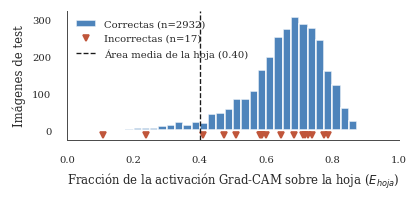

In [12]:
with plt.rc_context(PAPER_RC):
    fig, ax = plt.subplots(figsize=(COL_W, 1.7))
    ok, bad = cam_df[cam_df.correcta], cam_df[~cam_df.correcta]
    ax.hist(ok.energia_hoja, bins=np.linspace(0, 1, 41), color="#2f6fb0", alpha=0.85,
            label=f"Correctas (n={len(ok)})")
    # Los errores son pocos: se marcan individualmente en lugar de un histograma
    ax.plot(bad.energia_hoja, np.full(len(bad), -12), "v", color="#c0563b", ms=3.5,
            label=f"Incorrectas (n={len(bad)})", clip_on=False)
    ax.axvline(cam_df.area_hoja.mean(), color="k", ls="--", lw=0.8,
               label=f"Área media de la hoja ({cam_df.area_hoja.mean():.2f})")
    ax.set_xlim(0, 1); ax.set_ylim(bottom=-25)
    ax.set_xlabel("Fracción de la activación Grad-CAM sobre la hoja ($E_{hoja}$)")
    ax.set_ylabel("Imágenes de test")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, loc="upper left")
    fig.tight_layout()
    save_fig(fig, "gradcam_energia_hoja")
    plt.show()

## 10. Grad-CAM sobre los errores del modelo

Mostramos los errores de test ordenados por confianza: los errores con alta confianza son los más preocupantes para un sistema de diagnóstico. Para cada uno vemos dónde miró el modelo al equivocarse. El contorno blanco marca la máscara de la hoja.

17 errores de 2949 imágenes de test


,clase,pred,conf,energia_hoja,pico_en_hoja
1376,Tomate: tizón tardío,Tomate: tizón temprano,0.987,0.643,True
2500,Tomate: TYLCV,Tomate: tizón tardío,0.986,0.108,True
1689,Tomate: septoriosis,Tomate: tizón temprano,0.959,0.508,True
2202,Tomate: mancha diana,Tomate: ácaro araña,0.932,0.773,True
1340,Tomate: tizón tardío,Tomate: tizón temprano,0.892,0.716,True
337,Pimiento: sana,Pimiento: mancha bacteriana,0.869,0.712,True
253,Pimiento: sana,Pimiento: mancha bacteriana,0.869,0.738,True
1949,Tomate: ácaro araña,Tomate: mancha diana,0.842,0.587,True
649,Papa: sana,Pimiento: sana,0.827,0.787,True
1280,Tomate: tizón tardío,Tomate: tizón temprano,0.788,0.581,False


Figura exportada: paper/figures/gradcam_errores.pdf


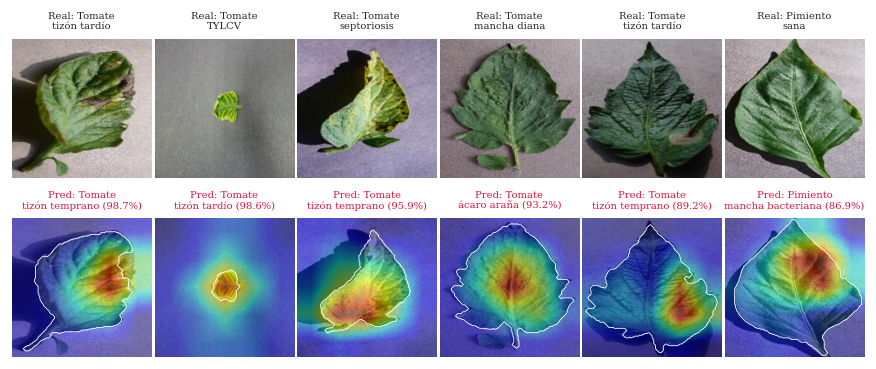

In [13]:
def cam_panel(relpath, class_idx=None):
    img = Image.open(DATA_DIR / relpath).convert("RGB")
    cam, probs, pred = gradcam.generate_cam(eval_tf(img).unsqueeze(0).to(DEVICE), class_idx=class_idx)
    img_np, _, overlay = GradCAM.overlay_cam(img, cam, alpha=0.45)
    return img_np, overlay, leaf_mask(img.resize((IMG_SIZE, IMG_SIZE))), probs, pred

def paper_grid(rows_df, name, title_fn):
    n = len(rows_df)
    with plt.rc_context(PAPER_RC):
        fig, axes = plt.subplots(2, n, figsize=(PAGE_W, PAGE_W / n * 2 + 0.75), squeeze=False)
        for j, (_, r) in enumerate(rows_df.iterrows()):
            img_np, overlay, mask, probs, pred = cam_panel(test_df.loc[r["idx"], "relpath"])
            axes[0, j].imshow(img_np)
            axes[0, j].set_title(f"Real: {es_two_lines[r['y']]}", fontsize=6)
            axes[1, j].imshow(overlay)
            axes[1, j].contour(mask, levels=[0.5], colors="white", linewidths=0.5)
            axes[1, j].set_title(title_fn(r, pred, probs), fontsize=6,
                                 color="forestgreen" if pred == r["y"] else "crimson")
        for ax in axes.ravel(): ax.axis("off")
        fig.tight_layout(pad=0.3, h_pad=0.6, w_pad=0.3)
        save_fig(fig, name)
        plt.show()

errors = cam_df[~cam_df.correcta].sort_values("conf", ascending=False)
print(f"{len(errors)} errores de {len(cam_df)} imágenes de test")
display(errors[["clase", "pred", "conf", "energia_hoja", "pico_en_hoja"]]
        .assign(pred=lambda d: d.pred.map(dict(enumerate(es_classes)))).round(3))

if len(errors):
    paper_grid(errors.head(6), "gradcam_errores",
               lambda r, pred, probs: f"Pred: {es_two_lines[pred]} ({probs[pred]*100:.1f}%)")

## 11. Figura de aciertos para el paper

Una muestra correctamente clasificada por enfermedad para seis patologías con síntomas visualmente distintos (lesiones necróticas, manchas pequeñas, moho, virosis). Se elige, dentro de cada clase, la imagen con la mediana de energía sobre la hoja, para mostrar un caso **típico** y no el más favorable.

Figura exportada: paper/figures/gradcam_aciertos.pdf


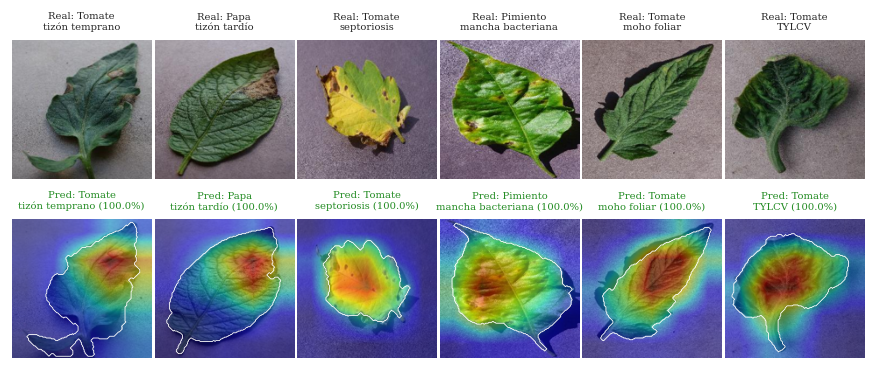

{'modelo': 'effb0_aug',
 'img_size': 160,
 'n_test': 2949,
 'errores_test': 17,
 'energia_hoja_media': 0.6574793916995261,
 'area_hoja_media': 0.40188555707443196,
 'energia_sobre_area_media': 1.7063644696172184,
 'pointing_game': 0.9650729060698542,
 'latencia': [{'modelo': 'mobilenet_v3_small',
   'dispositivo': 'cpu',
   'params (M)': 1.533,
   'tamaño fp32 (MB)': 5.895,
   'latencia bs=1 media (ms)': 7.149,
   'latencia bs=1 p95 (ms)': 9.095,
   'throughput bs=32 (img/s)': 931.172},
  {'modelo': 'efficientnet_b0',
   'dispositivo': 'cpu',
   'params (M)': 4.027,
   'tamaño fp32 (MB)': 15.522,
   'latencia bs=1 media (ms)': 17.5,
   'latencia bs=1 p95 (ms)': 20.54,
   'throughput bs=32 (img/s)': 150.847}]}

In [14]:
fig_classes = ["Tomato_Early_blight", "Potato___Late_blight", "Tomato_Septoria_leaf_spot",
               "Pepper__bell___Bacterial_spot", "Tomato_Leaf_Mold", "Tomato__Tomato_YellowLeaf__Curl_Virus"]
typical = []
for c in fig_classes:
    ok = cam_df[(cam_df.y == classes.index(c)) & cam_df.correcta].sort_values("energia_hoja")
    typical.append(ok.iloc[len(ok) // 2])
paper_grid(pd.DataFrame(typical), "gradcam_aciertos",
           lambda r, pred, probs: f"Pred: {es_two_lines[pred]} ({probs[pred]*100:.1f}%)")

# Resumen numérico para el paper
resumen = {
    "modelo": BEST_NAME, "img_size": IMG_SIZE, "n_test": int(len(cam_df)),
    "errores_test": int((~cam_df.correcta).sum()),
    "energia_hoja_media": float(cam_df.energia_hoja.mean()),
    "area_hoja_media": float(cam_df.area_hoja.mean()),
    "energia_sobre_area_media": float(cam_df["energia/area"].mean()),
    "pointing_game": float(cam_df.pico_en_hoja.mean()),
    "latencia": latency.round(3).reset_index().to_dict(orient="records"),
}
json.dump(resumen, open(RES_DIR / "resumen.json", "w", encoding="utf-8"), indent=2, ensure_ascii=False)
resumen

### Figura combinada para el paper

Por espacio, el paper usa una única figura de ancho de página con tres aciertos típicos (lesiones necróticas, tizón y virosis) y los tres errores con mayor confianza. Las figuras separadas de aciertos y errores quedan disponibles en `paper/figures/` como material complementario.

Figura exportada: paper/figures/gradcam_ejemplos.pdf


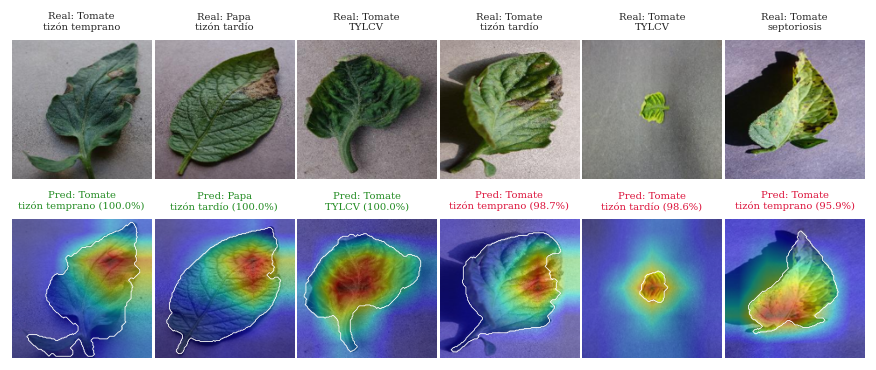

In [15]:
combo_classes = ["Tomato_Early_blight", "Potato___Late_blight", "Tomato__Tomato_YellowLeaf__Curl_Virus"]
combo_ok = [t for t in typical if classes[int(t["y"])] in combo_classes]
paper_grid(pd.concat([pd.DataFrame(combo_ok), errors.head(3)], ignore_index=True), "gradcam_ejemplos",
           lambda r, pred, probs: f"Pred: {es_two_lines[pred]} ({probs[pred]*100:.1f}%)")

## 12. Conclusiones

El uso de GradCam permite dar una explicacion a la predicción realizada por el modelo. Esto puede ser útil durante la etapa del desarrollo del mismo para validar que le de importancia a las regiones relevantes y tambien durante inferecia para darle mayor confianza al usuario final.

Tras observar el comportamiento de GradCam con nuestro modelo, vemos que en muchos casos se focaliza en las partes que permiten identificar correctamente la clase.